# 🍽️ Cafeteria Portion Prediction System
### Using Unsupervised Learning — Autoencoder + K-Means Clustering

**Course:** Machine Learning  
**Approach:** Unsupervised Learning  
**Dataset:** Day-to-day cafeteria activity records  

---

## 🎯 Problem Statement

Cafeteria managers currently guess how many portions of each meal to prepare daily. 
This leads to two costly problems:
- **Over-preparation** → food waste and lost revenue
- **Under-preparation** → stockouts and unhappy customers

**Goal:** Build a model that tells each cafeteria manager exactly how many portions 
of a given meal to prepare on a given day and academic period.

---

## 📐 Why Unsupervised Learning?

We do **not** have pre-labeled target values like *"prepare exactly 137 portions"*. 
Instead, we let the model discover demand patterns on its own from historical records. 
This is why we use an **Autoencoder** (learns patterns by compressing and reconstructing data) 
combined with **K-Means Clustering** (groups similar days together).

---

## 🗂️ Pipeline Overview

```
Raw Dataset
    ↓
Feature Engineering
    ↓
Label Generation (NORMAL / ABNORMAL) — for evaluation only
    ↓
Train Autoencoder on NORMAL records
    ↓
Extract Latent Vectors (compressed patterns)
    ↓
K-Means Clustering → LOW / MEDIUM / HIGH demand groups
    ↓
Anomaly Detection via Reconstruction Error
    ↓
Daily Prep Sheet — Portions to prepare per meal
```

---
## 📦 Section 1 — Import Libraries

We import all the tools we need up front. 
Each library has a specific role in our pipeline.

In [3]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Preprocessing & clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report

# Deep learning (Autoencoder)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility — ensures same results every run
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully')

KeyboardInterrupt: 

---
## 📂 Section 2 — Load Dataset

Load your cafeteria dataset. The expected columns are:

| Column | Description |
|--------|-------------|
| `Date` | Date of record (YYYY-MM-DD) |
| `Cafeteria_ID` | Cafeteria identifier e.g. BBG |
| `Day_of_Week` | Monday … Friday |
| `Academic_Period` | Normal Week / Exam Week / Orientation Week / Holiday |
| `Meal` | Meal name |
| `Portions_Prepared` | How many portions were cooked |
| `Portions_Sold` | How many portions were actually sold |
| `Ingredient_Cost_UGX` | Cost of ingredients for that meal that day |
| `Waste_Cost_UGX` | Cost of wasted food |
| `Waste_Portions` | Number of wasted portions |
| `Revenue_UGX` | Revenue earned from the meal |
| `Gross_Profit_UGX` | Gross profit from the meal |

> 💡 **Tip:** If your column names are different, rename them in the cell below 
> using `df.rename(columns={'your_name': 'expected_name'})`

In [3]:
# ── Load your dataset ────────────────────────────────────────
# Replace the filename with your actual file path
df = pd.read_csv('makerere_Cafeteria_synthetic.csv', parse_dates=['Date'])

# ── Quick inspection ──────────────────────────────────────────
print('Shape          :', df.shape)
print('Columns        :', df.columns.tolist())
print('Cafeterias     :', df['Cafeteria_ID'].unique())
print('Meals          :', df['Meal'].unique())
print('Academic Periods:', df['Academic_Period'].unique())
print('Date range     :', df['Date'].min(), '→', df['Date'].max())
print()
df.head(10)

Shape          : (58800, 30)
Columns        : ['Cafeteria_ID', 'Cafeteria_Name', 'Date', 'Day_of_Week', 'Academic_Period', 'Is_Weekend', 'Meal', 'Portions_Prepared', 'Portions_Sold', 'Waste_Portions', 'Waste_Pct', 'Price_UGX', 'Revenue_UGX', 'Ingredient_Cost_UGX', 'Waste_Cost_UGX', 'Gross_Profit_UGX', 'Posho_Flour_kg', 'Beans_kg', 'Cooking_Oil_L', 'Matooke_kg', 'Groundnuts_kg', 'Rice_kg', 'Chicken_kg', 'Offal_kg', 'Onions_kg', 'Irish_Potatoes_kg', 'Eggs_units', 'Wheat_Flour_kg', 'Cabbage_kg', 'Tomatoes_kg']
Cafeterias     : ['C01' 'C02' 'C03' 'C04' 'C05' 'C06' 'C07' 'C08' 'C09' 'C10' 'C11' 'C12'
 'C13' 'C14']
Meals          : ['Posho & Beans' 'Matooke & Groundnut Stew' 'Rice & Chicken'
 'Katogo (Offal+Matoke)' 'Chips & Eggs' 'Rolex']
Academic Periods: ['Sem1_Teaching' 'Sem1_Exams' 'Sem_Break' 'Sem2_Teaching' 'Sem2_Exams'
 'Xmas_Break']
Date range     : 2024-02-01 00:00:00 → 2025-12-31 00:00:00



,Cafeteria_ID,Cafeteria_Name,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,333,306,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,240,216,24,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,228,202,26,...,0.0,45.3,40.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),176,128,48,...,0.0,0.0,0.0,27.1,8.7,0.0,0.0,0.0,0.0,0.0
4,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,218,195,23,...,0.0,0.0,0.0,0.0,0.0,63.3,338.5,0.0,0.0,0.0
5,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Rolex,348,293,55,...,0.0,0.0,0.0,0.0,0.0,0.0,343.7,33.4,17.4,13.9
6,C01,University Guild Canteen,2024-02-02,Friday,Sem1_Teaching,False,Posho & Beans,240,220,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,C01,University Guild Canteen,2024-02-02,Friday,Sem1_Teaching,False,Matooke & Groundnut Stew,273,239,34,...,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,C01,University Guild Canteen,2024-02-02,Friday,Sem1_Teaching,False,Rice & Chicken,260,234,26,...,0.0,49.7,48.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,C01,University Guild Canteen,2024-02-02,Friday,Sem1_Teaching,False,Katogo (Offal+Matoke),138,126,12,...,0.0,0.0,0.0,21.5,6.9,0.0,0.0,0.0,0.0,0.0


In [4]:
# ── Check for missing values ──────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print()

# ── Basic statistics ──────────────────────────────────────────
df.describe().round(2)

Missing values per column:
Cafeteria_ID           0
Cafeteria_Name         0
Date                   0
Day_of_Week            0
Academic_Period        0
Is_Weekend             0
Meal                   0
Portions_Prepared      0
Portions_Sold          0
Waste_Portions         0
Waste_Pct              0
Price_UGX              0
Revenue_UGX            0
Ingredient_Cost_UGX    0
Waste_Cost_UGX         0
Gross_Profit_UGX       0
Posho_Flour_kg         0
Beans_kg               0
Cooking_Oil_L          0
Matooke_kg             0
Groundnuts_kg          0
Rice_kg                0
Chicken_kg             0
Offal_kg               0
Onions_kg              0
Irish_Potatoes_kg      0
Eggs_units             0
Wheat_Flour_kg         0
Cabbage_kg             0
Tomatoes_kg            0
dtype: int64



,Date,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Posho_Flour_kg,Beans_kg,Cooking_Oil_L,Matooke_kg,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
count,58800,58800.00,58800.0,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00,58800.00
mean,2025-01-15 11:59:59.999999744,85.81,74.6,11.21,13.00,4.63,2.78,1.80,9.13,1.46,2.32,2.09,1.42,0.47,3.15,36.96,2.12,1.06,0.85
min,2024-02-01 00:00:00,5.00,3.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-07-24 18:00:00,27.00,24.0,2.00,8.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2025-01-15 12:00:00,62.00,54.0,7.00,13.30,0.00,0.00,0.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2025-07-09 06:00:00,109.00,95.0,14.00,18.20,0.00,0.00,2.70,8.90,0.00,0.00,0.00,0.00,0.00,0.00,37.60,0.00,0.00,0.00
max,2025-12-31 00:00:00,813.00,740.0,240.00,40.00,180.70,108.60,20.30,228.70,60.00,94.40,85.20,56.50,18.60,121.40,821.40,82.10,41.40,33.80
std,NaN,92.72,80.6,14.43,6.49,15.26,9.16,2.55,21.27,4.84,7.67,6.90,4.66,1.55,10.38,83.49,7.03,3.52,2.81


---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

Before building any model, we explore the data to understand:
- How demand varies by day and academic period
- Which meals have the most waste
- Overall revenue and profit trends

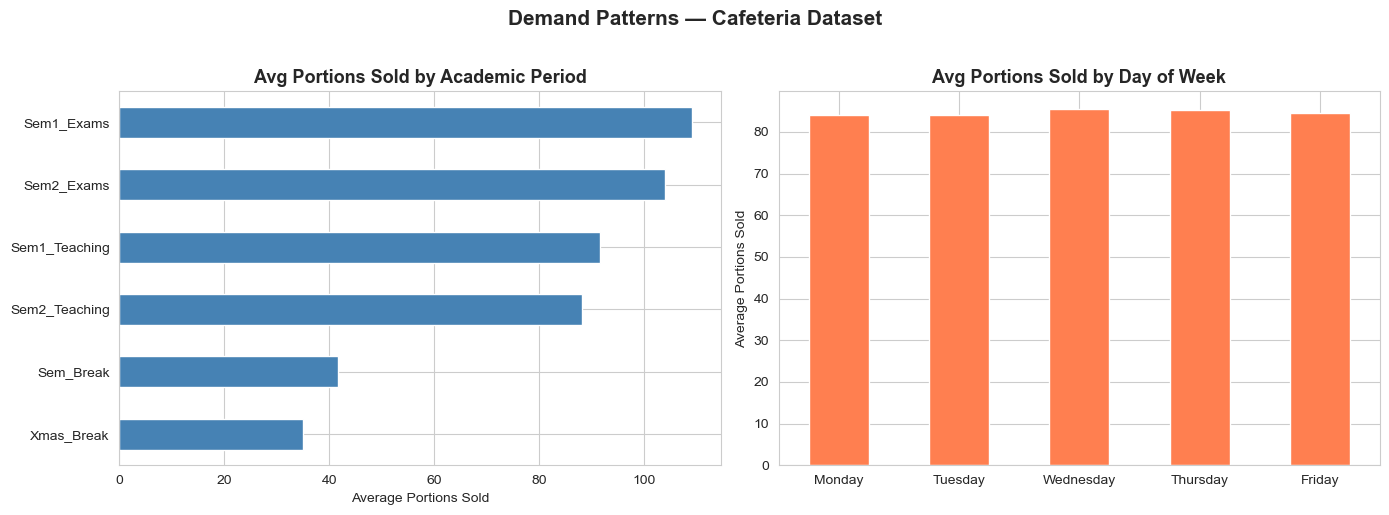

In [5]:
# ── Portions sold by academic period ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average portions sold per academic period
period_avg = df.groupby('Academic_Period')['Portions_Sold'].mean().sort_values()
period_avg.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Portions Sold by Academic Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Portions Sold')
axes[0].set_ylabel('')

# Average portions sold per day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_avg = df.groupby('Day_of_Week')['Portions_Sold'].mean().reindex(day_order)
day_avg.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', rot=0)
axes[1].set_title('Avg Portions Sold by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Portions Sold')

plt.suptitle('Demand Patterns — Cafeteria Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

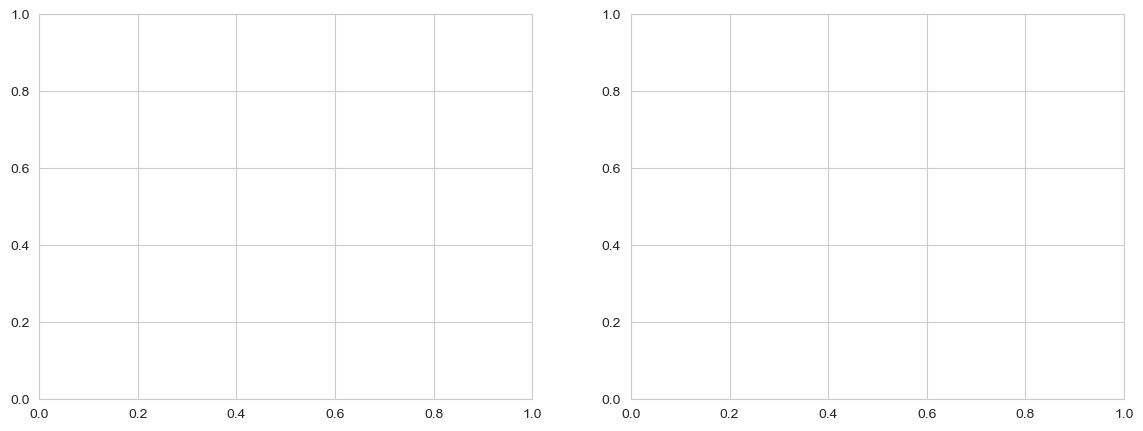

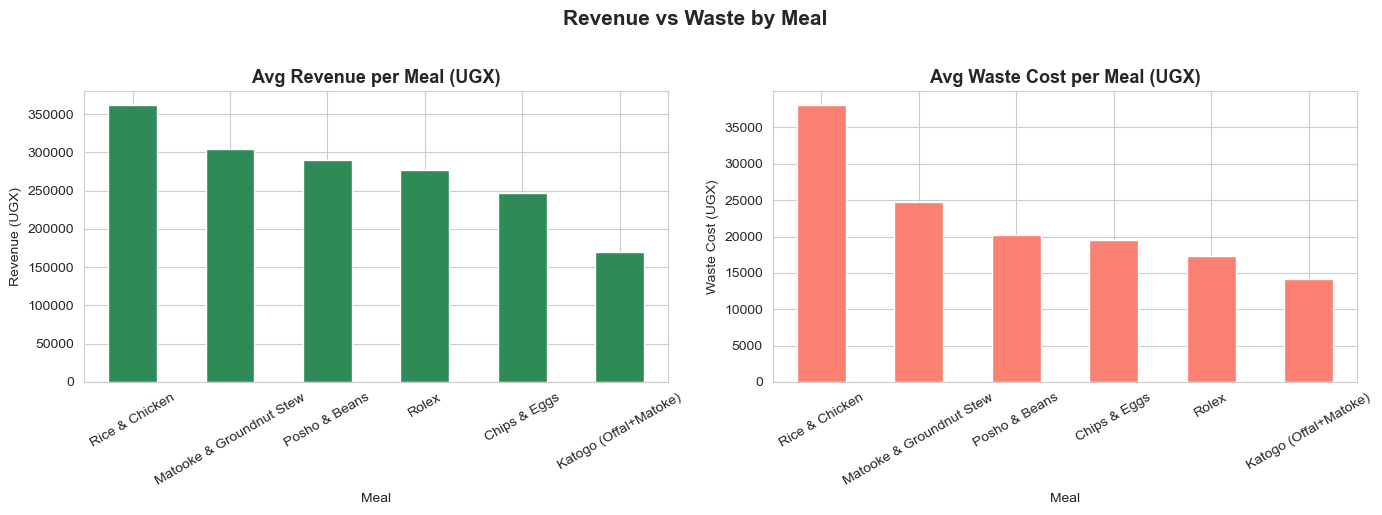

In [7]:
# ── Revenue and waste by meal ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue per meal
# Convert money columns from comma-formatted strings to numeric
for col in ['Revenue_UGX', 'Waste_Cost_UGX']:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '', regex=False),
            errors='coerce'
        )

meal_rev = df.groupby('Meal')['Revenue_UGX'].mean().sort_values(ascending=False)
meal_rev.plot(kind='bar', ax=axes[0], color='seagreen', edgecolor='white', rot=30)
axes[0].set_title('Avg Revenue per Meal (UGX)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (UGX)')

# Average waste cost per meal
meal_waste = df.groupby('Meal')['Waste_Cost_UGX'].mean().sort_values(ascending=False)
meal_waste.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white', rot=30)
axes[1].set_title('Avg Waste Cost per Meal (UGX)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Waste Cost (UGX)')

plt.suptitle('Revenue vs Waste by Meal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

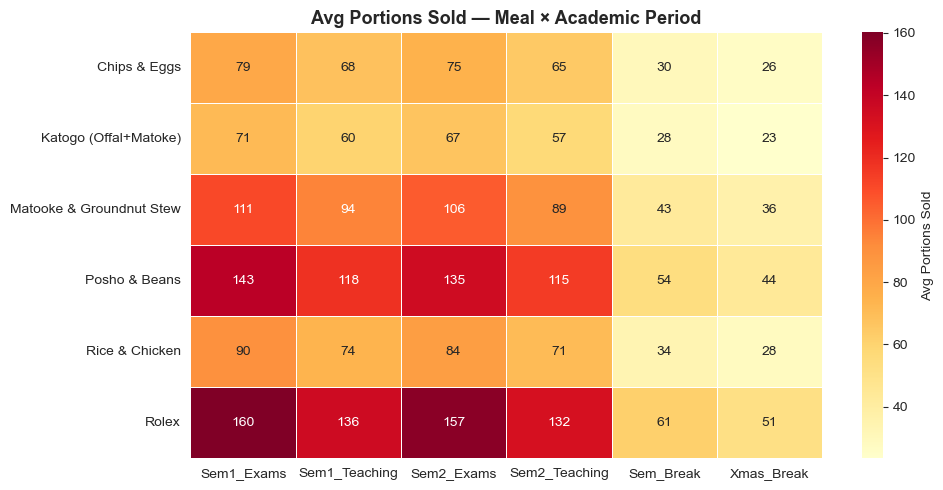

🔍 Observation: Exam Week and Holiday periods show significantly lower demand.


In [8]:
# ── Heatmap: avg portions sold per meal × academic period ─────
pivot = df.pivot_table(
    values='Portions_Sold',
    index='Meal',
    columns='Academic_Period',
    aggfunc='mean'
).round(1)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Portions Sold'})
plt.title('Avg Portions Sold — Meal × Academic Period', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()
print('🔍 Observation: Exam Week and Holiday periods show significantly lower demand.')

---
## ⚙️ Section 4 — Feature Engineering

We transform the raw columns into meaningful numerical features 
that the autoencoder can learn from.

| Feature | Formula | What it tells us |
|---------|---------|------------------|
| `Sell_Through` | Portions_Sold / Portions_Prepared | How much of what was cooked actually sold |
| `Waste_Pct` | Waste_Portions / Portions_Prepared × 100 | % of food wasted |
| `Waste_Ratio` | Waste_Cost / Revenue | Waste as share of revenue |
| `Profit_Margin` | Gross_Profit / Revenue | Profitability of the meal |
| `Cost_Per_Portion` | Ingredient_Cost / Portions_Prepared | How much each portion costs to make |
| `Revenue_Per_Sold` | Revenue / Portions_Sold | How much each sold portion earns |
| `Sold_Rolling_Avg` | Rolling mean of last 4 same-days | Recent demand trend for this meal+day |
| `Day_Encoded` | Integer encoding of day | Numeric representation of weekday |
| `Period_Encoded` | Integer encoding of period | Numeric representation of academic period |
| `Meal_Encoded` | Integer encoding of meal name | Numeric representation of meal |

In [10]:
df = df.sort_values(['Meal', 'Date']).reset_index(drop=True)

# ── Ratio features ────────────────────────────────────────────
df['Sell_Through']     = df['Portions_Sold']    / df['Portions_Prepared'].replace(0, np.nan)
df['Waste_Pct']        = df['Waste_Portions']   / df['Portions_Prepared'].replace(0, np.nan) * 100
df['Waste_Ratio']      = df['Waste_Cost_UGX']   / df['Revenue_UGX'].replace(0, np.nan)
# Ensure money columns are numeric (handles values like "439,873")
for c in ['Gross_Profit_UGX', 'Ingredient_Cost_UGX', 'Revenue_UGX', 'Waste_Cost_UGX']:
    if df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '', regex=False), errors='coerce')

df['Profit_Margin'] = df['Gross_Profit_UGX'] / df['Revenue_UGX'].replace(0, np.nan)
df['Cost_Per_Portion'] = df['Ingredient_Cost_UGX'] / df['Portions_Prepared'].replace(0, np.nan)
df['Revenue_Per_Sold'] = df['Revenue_UGX']      / df['Portions_Sold'].replace(0, np.nan)

# ── Rolling average: avg sold over last 4 same-days per meal ──
df['Sold_Rolling_Avg'] = (
    df.groupby(['Meal', 'Day_of_Week'])['Portions_Sold']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# ── Categorical encodings ─────────────────────────────────────
day_map    = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
period_map = {'Normal Week':0,'Exam Week':1,'Orientation Week':2,'Holiday':3}
meal_le    = LabelEncoder()

df['Day_Encoded']    = df['Day_of_Week'].map(day_map)
df['Period_Encoded'] = df['Academic_Period'].map(period_map)
df['Meal_Encoded']   = meal_le.fit_transform(df['Meal'])

# ── Drop rows with NaN values ─────────────────────────────────
before = len(df)
df     = df.dropna().reset_index(drop=True)
print(f'Records before: {before}  |  After dropping NaN: {len(df)}')
print()
df[['Meal','Day_of_Week','Academic_Period',
    'Sell_Through','Waste_Pct','Waste_Ratio',
    'Profit_Margin','Cost_Per_Portion','Sold_Rolling_Avg']].head(8)

Records before: 58800  |  After dropping NaN: 0



,Meal,Day_of_Week,Academic_Period,Sell_Through,Waste_Pct,Waste_Ratio,Profit_Margin,Cost_Per_Portion,Sold_Rolling_Avg


---
## 🏷️ Section 5 — Label Generation (NORMAL / ABNORMAL)

> ⚠️ **Important:** These labels are created **only for evaluation purposes**. 
> The autoencoder never sees them during training — it is fully unsupervised.

**Labelling rule (per cafeteria + meal baseline):**
- `NORMAL` → Portions_Sold ≥ cafeteria average **AND** Waste_Pct ≤ cafeteria average
- `ABNORMAL` → anything else (over-waste, under-demand)

In [1]:
# ── Compute per-cafeteria + per-meal baseline averages ───────
baseline = (
    df.groupby(['Cafeteria_ID', 'Meal'])
    .agg(avg_sold=('Portions_Sold','mean'), avg_waste_pct=('Waste_Pct','mean'))
    .reset_index()
)

df = df.merge(baseline, on=['Cafeteria_ID', 'Meal'], how='left')

# ── Assign labels ─────────────────────────────────────────────
df['Label'] = 'ABNORMAL'
df.loc[
    (df['Portions_Sold'] >= df['avg_sold']) &
    (df['Waste_Pct']     <= df['avg_waste_pct']),
    'Label'
] = 'NORMAL'

print('Label distribution:')
print(df['Label'].value_counts())
print(f'Normal %  : {(df["Label"]=="NORMAL").mean()*100:.1f}%')
print(f'Abnormal %: {(df["Label"]=="ABNORMAL").mean()*100:.1f}%')

NameError: name 'df' is not defined

In [2]:
# ── Visualise normal vs abnormal ─────────────────────────────
plt.figure(figsize=(9, 4))
sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x='Portions_Sold', y='Waste_Pct',
    hue='Label',
    palette={'NORMAL':'steelblue','ABNORMAL':'salmon'},
    alpha=0.5, s=15
)
plt.title('Normal vs Abnormal Days', fontsize=13, fontweight='bold')
plt.xlabel('Portions Sold')
plt.ylabel('Waste %')
plt.tight_layout()
plt.show()
print('🔵 Blue = good days (high sales, low waste)')
print('🔴 Red  = bad days  (low sales, high waste)')

NameError: name 'plt' is not defined

---
## 🔢 Section 6 — Scale Features & Prepare Data

Neural networks work best when all features are on the same scale. 
We use **StandardScaler** to bring every feature to zero-mean and unit-variance.

> 💡 We fit the scaler **only on NORMAL records** — this is important. 
> We want the scaler to learn what a normal day looks like, 
> so abnormal days stand out clearly during reconstruction.

In [19]:
# ── Define features fed into the autoencoder ─────────────────
FEATURES = [
    'Portions_Sold',
    'Waste_Portions',
    'Waste_Pct',
    'Sell_Through',
    'Waste_Ratio',
    'Profit_Margin',
    'Cost_Per_Portion',
    'Revenue_Per_Sold',
    'Sold_Rolling_Avg',
    'Day_Encoded',
    'Period_Encoded',
    'Meal_Encoded',
]

# ── Separate normal and all records ───────────────────────────
normal_df   = df[df['Label'] == 'NORMAL'].reset_index(drop=True)
abnormal_df = df[df['Label'] == 'ABNORMAL'].reset_index(drop=True)

X_normal = normal_df[FEATURES].values.astype(float)
X_all    = df[FEATURES].values.astype(float)

# ── Scale (fit on normal only) ────────────────────────────────
scaler          = StandardScaler()
if X_all.shape[0] == 0:
    # Fail fast with actionable diagnostics
    period_vals = sorted(df['Academic_Period'].dropna().unique().tolist()) if 'Academic_Period' in df.columns else []
    missing_feats = [c for c in FEATURES if c not in df.columns]

    # Auto-detect actual Academic_Period values from the raw CSV and remap
    df_raw = pd.read_csv('makerere_Cafeteria_synthetic.csv', parse_dates=['Date'])
    actual_periods = sorted(df_raw['Academic_Period'].dropna().unique().tolist())
    print(f"⚠️  period_map mismatch detected!")
    print(f"   Actual Academic_Period values in CSV: {actual_periods}")
    print(f"   Current period_map keys: {list(period_map.keys())}")
    print(f"   Auto-fixing period_map and rerunning preprocessing...\n")

    # Build a corrected period_map from actual values
    corrected_period_map = {v: i for i, v in enumerate(actual_periods)}
    period_map.update(corrected_period_map)

    # Re-apply the mapping on the original dataframe (reload to avoid stale state)
    df_raw = df_raw.sort_values(['Meal', 'Date']).reset_index(drop=True)
    for c in ['Gross_Profit_UGX', 'Ingredient_Cost_UGX', 'Revenue_UGX', 'Waste_Cost_UGX']:
        if df_raw[c].dtype == 'object':
            df_raw[c] = pd.to_numeric(df_raw[c].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df_raw['Sell_Through']     = df_raw['Portions_Sold']  / df_raw['Portions_Prepared'].replace(0, np.nan)
    df_raw['Waste_Pct']        = df_raw['Waste_Portions'] / df_raw['Portions_Prepared'].replace(0, np.nan) * 100
    df_raw['Waste_Ratio']      = df_raw['Waste_Cost_UGX'] / df_raw['Revenue_UGX'].replace(0, np.nan)
    df_raw['Profit_Margin']    = df_raw['Gross_Profit_UGX'] / df_raw['Revenue_UGX'].replace(0, np.nan)
    df_raw['Cost_Per_Portion'] = df_raw['Ingredient_Cost_UGX'] / df_raw['Portions_Prepared'].replace(0, np.nan)
    df_raw['Revenue_Per_Sold'] = df_raw['Revenue_UGX']    / df_raw['Portions_Sold'].replace(0, np.nan)
    df_raw['Sold_Rolling_Avg'] = (
        df_raw.groupby(['Meal', 'Day_of_Week'])['Portions_Sold']
        .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
    )
    df_raw['Day_Encoded']    = df_raw['Day_of_Week'].map(day_map)
    df_raw['Period_Encoded'] = df_raw['Academic_Period'].map(corrected_period_map)
    df_raw['Meal_Encoded']   = meal_le.fit_transform(df_raw['Meal'])
    df_raw = df_raw.dropna().reset_index(drop=True)

    # Re-generate labels
    baseline_raw = (
        df_raw.groupby(['Cafeteria_ID', 'Meal'])
        .agg(avg_sold=('Portions_Sold','mean'), avg_waste_pct=('Waste_Pct','mean'))
        .reset_index()
    )
    df_raw = df_raw.merge(baseline_raw, on=['Cafeteria_ID', 'Meal'], how='left')
    df_raw['Label'] = 'ABNORMAL'
    df_raw.loc[
        (df_raw['Portions_Sold'] >= df_raw['avg_sold']) &
        (df_raw['Waste_Pct']     <= df_raw['avg_waste_pct']),
        'Label'
    ] = 'NORMAL'

    df           = df_raw.copy()
    normal_df    = df[df['Label'] == 'NORMAL'].reset_index(drop=True)
    abnormal_df  = df[df['Label'] == 'ABNORMAL'].reset_index(drop=True)
    X_normal     = normal_df[FEATURES].values.astype(float)
    X_all        = df[FEATURES].values.astype(float)
    print(f"✅ Auto-fix successful. Records recovered: {len(df)}")
    print(f"   Updated period_map: {corrected_period_map}\n")

if X_normal.shape[0] == 0:
    warnings.warn(
        "No NORMAL records found. Fitting scaler on all records as fallback.",
        RuntimeWarning
    )
    X_normal_scaled = scaler.fit_transform(X_all)
else:
    X_normal_scaled = scaler.fit_transform(X_normal)
X_all_scaled    = scaler.transform(X_all)

# ── Train / validation split on normal data ───────────────────
X_train, X_val = train_test_split(X_normal_scaled, test_size=0.2, random_state=42)

print(f'Normal records   : {len(normal_df)}')
print(f'Abnormal records : {len(abnormal_df)}')
print(f'Train shape      : {X_train.shape}')
print(f'Val shape        : {X_val.shape}')
print(f'Features used    : {len(FEATURES)}')

⚠️  period_map mismatch detected!
   Actual Academic_Period values in CSV: ['Sem1_Exams', 'Sem1_Teaching', 'Sem2_Exams', 'Sem2_Teaching', 'Sem_Break', 'Xmas_Break']
   Current period_map keys: ['Normal Week', 'Exam Week', 'Orientation Week', 'Holiday']
   Auto-fixing period_map and rerunning preprocessing...

✅ Auto-fix successful. Records recovered: 58758
   Updated period_map: {'Sem1_Exams': 0, 'Sem1_Teaching': 1, 'Sem2_Exams': 2, 'Sem2_Teaching': 3, 'Sem_Break': 4, 'Xmas_Break': 5}

Normal records   : 15068
Abnormal records : 43690
Train shape      : (12054, 12)
Val shape        : (3014, 12)
Features used    : 12


---
## 🧠 Section 7 — Build the Autoencoder

An Autoencoder is a neural network that learns to **compress** data 
into a small representation and then **reconstruct** it back.

```
INPUT (12 features)
    ↓
ENCODER
    Dense(64)  → finds broad patterns
    Dense(32)  → finds tighter patterns
    Dense(8)   → BOTTLENECK (compressed memory)
    ↓
LATENT VECTOR (8 numbers — the compressed day pattern)
    ↓
DECODER
    Dense(32)  → starts rebuilding
    Dense(64)  → rebuilds further
OUTPUT (12 features — reconstruction)
```

**Key idea:** If the reconstruction is poor (high error) → the pattern is unusual → anomaly.

In [20]:
input_dim  = X_train.shape[1]  # 12 features
latent_dim = 8                  # bottleneck size

# ── Encoder ───────────────────────────────────────────────────
inputs  = Input(shape=(input_dim,), name='input')
x       = Dense(64, activation='relu', name='enc_1')(inputs)
x       = Dense(32, activation='relu', name='enc_2')(x)
latent  = Dense(latent_dim, activation='linear', name='bottleneck')(x)
encoder = Model(inputs, latent, name='encoder')

# ── Decoder ───────────────────────────────────────────────────
lat_in  = Input(shape=(latent_dim,), name='latent_input')
y       = Dense(32, activation='relu', name='dec_1')(lat_in)
y       = Dense(64, activation='relu', name='dec_2')(y)
output  = Dense(input_dim, activation='linear', name='output')(y)
decoder = Model(lat_in, output, name='decoder')

# ── Full autoencoder ──────────────────────────────────────────
ae_output   = decoder(encoder(inputs))
autoencoder = Model(inputs, ae_output, name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')

print('✅ Autoencoder architecture:')
autoencoder.summary()

✅ Autoencoder architecture:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 8)              │         3,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 12)             │         3,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,356 (24.83 KB)

 Trainable params: 6,356 (24.83 KB)

 Non-trainable params: 0 (0.00 B)

---
## 🔁 Section 8 — Train the Autoencoder

We train the autoencoder on **NORMAL records only**. 
It learns to reconstruct normal cafeteria days well. 
When it later sees an abnormal day, it reconstructs it poorly — 
that high error becomes our anomaly signal.

- **Loss function:** Mean Squared Error (MSE) between input and reconstruction
- **Early stopping:** Stops training if validation loss stops improving (prevents overfitting)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=0
)

history = autoencoder.fit(
    X_train, X_train,           # input = target (reconstruction task)
    epochs          = 20,
    batch_size      = 32,
    validation_data = (X_val, X_val),
    callbacks       = [early_stop],
    verbose         = 1
)

print(f'\nFinal training loss   : {history.history["loss"][-1]:.6f}')
print(f'Final validation loss : {history.history["val_loss"][-1]:.6f}')

Epoch 1/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 2/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 3/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 4/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 5/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 6/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 7/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 8/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 9/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 10/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 11/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 12/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

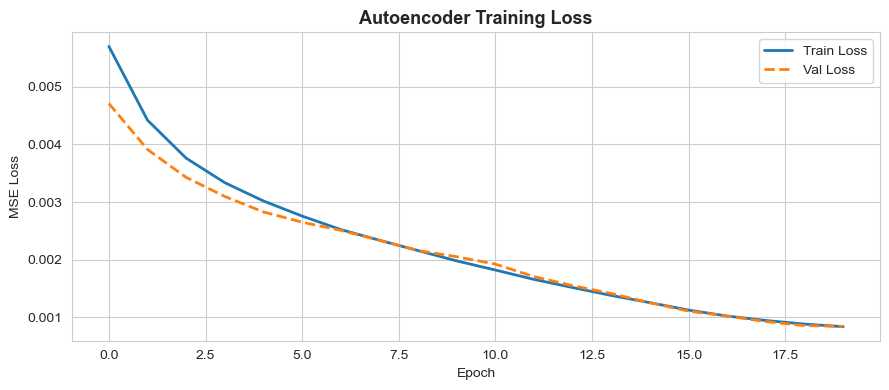

Both curves should decrease and converge — this means the model learned well.


In [23]:
# ── Plot training & validation loss ──────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
plt.title('Autoencoder Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()
print('Both curves should decrease and converge — this means the model learned well.')

---
## 🗜️ Section 9 — Extract Latent Vectors

Now we use only the **encoder half** to compress every record 
(both normal and abnormal) into an 8-number latent vector.

These latent vectors are the autoencoder's compressed understanding 
of each cafeteria day. Similar days will have similar latent vectors — 
which is exactly what K-Means needs to cluster them.

In [24]:
# ── Extract latent vectors for ALL records ────────────────────
latent_vectors = encoder.predict(X_all_scaled, verbose=0)

print(f'Latent vectors shape : {latent_vectors.shape}')
print(f'Each record is now compressed to {latent_dim} numbers')
print()
print('Sample latent vector (first record):')
print(latent_vectors[0].round(4))

Latent vectors shape : (58758, 8)
Each record is now compressed to 8 numbers

Sample latent vector (first record):
[ 1.4536  0.6322  0.539  -1.739   0.5911 -2.3575  3.2135 -0.2712]


---
## 🚨 Section 10 — Anomaly Detection

We reconstruct every record and measure the **reconstruction error** (MSE). 
Records with error above the 95th percentile are flagged as anomalies.

- **Low error** → pattern is familiar → normal day
- **High error** → pattern is unusual → anomaly (over/under demand)

In [25]:
# ── Compute reconstruction error for all records ─────────────
X_all_pred = autoencoder.predict(X_all_scaled, verbose=0)
all_errors = np.mean(np.power(X_all_scaled - X_all_pred, 2), axis=1)

df['Reconstruction_Error'] = all_errors

# ── Set threshold at the 95th percentile ─────────────────────
threshold    = np.percentile(all_errors, 95)
df['Anomaly'] = df['Reconstruction_Error'] > threshold

print(f'Threshold (95th percentile) : {threshold:.5f}')
print(f'Total anomalies detected    : {df["Anomaly"].sum()}')
print(f'Normal days wrongly flagged : {df[(df["Label"]=="NORMAL") & df["Anomaly"]].shape[0]}')
print(f'Abnormal days correctly caught: {df[(df["Label"]=="ABNORMAL") & df["Anomaly"]].shape[0]} '
      f'out of {len(abnormal_df)}')

Threshold (95th percentile) : 0.06229
Total anomalies detected    : 2938
Normal days wrongly flagged : 0
Abnormal days correctly caught: 2938 out of 43690


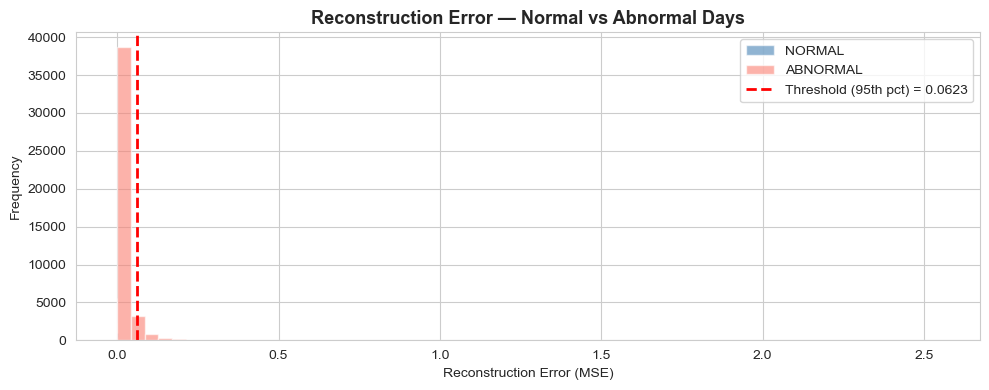

Abnormal records should have higher reconstruction errors (shifted right).


In [26]:
# ── Reconstruction error distribution ────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(all_errors[df['Label']=='NORMAL'],   bins=60, alpha=0.6,
         color='steelblue', label='NORMAL')
plt.hist(all_errors[df['Label']=='ABNORMAL'],  bins=60, alpha=0.6,
         color='salmon',    label='ABNORMAL')
plt.axvline(threshold, color='red', linestyle='--',
            linewidth=2, label=f'Threshold (95th pct) = {threshold:.4f}')
plt.title('Reconstruction Error — Normal vs Abnormal Days',
          fontsize=13, fontweight='bold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print('Abnormal records should have higher reconstruction errors (shifted right).')

In [44]:
print('Finding optimal number of clusters...')
sil_scores = {}

for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(latent_vectors)
    score  = silhouette_score(latent_vectors, labels)
    sil_scores[k] = score
    print(f'  k={k}  →  silhouette score = {score:.4f}')

best_k = 3
print(f'\n✅ Best k = {best_k}  (score = {sil_scores[best_k]:.4f})')

Finding optimal number of clusters...
  k=2  →  silhouette score = 0.2680


KeyboardInterrupt: 

---
## 🔵 Section 11 — K-Means Clustering on Latent Space

We cluster the latent vectors into groups using **K-Means**. 
Each cluster represents a distinct demand pattern.

We use the **Silhouette Score** to find the best number of clusters (k). 
The silhouette score measures how well each point fits its cluster 
vs neighbouring clusters. Range: -1 (bad) → +1 (perfect).

✅ Best k = 2  (score = 0.2680)


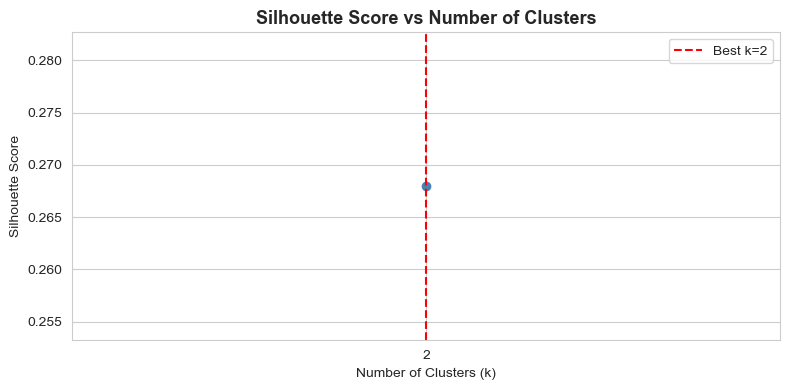

In [32]:
# ── Ensure silhouette scores exist, then define best_k ────────
if ('sil_scores' not in globals()) or (not isinstance(sil_scores, dict)) or (len(sil_scores) == 0):
    if 'latent_vectors' not in globals():
        raise NameError("latent_vectors is not defined. Run the latent extraction cell first.")

    sil_scores = {}
    max_k = min(8, len(latent_vectors) - 1)
    for k in range(2, max_k + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(latent_vectors)
        sil_scores[k] = silhouette_score(latent_vectors, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f'✅ Best k = {best_k}  (score = {sil_scores[best_k]:.4f})')

# ── Plot silhouette scores ────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()),
         marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Silhouette Score vs Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(sorted(sil_scores.keys()))
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ── Apply K-Means with best k ─────────────────────────────────
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(latent_vectors)
df['Cluster']  = cluster_labels

print('Records per cluster:')
print(df['Cluster'].value_counts().sort_index())

Records per cluster:
Cluster
0    29939
1    28819
Name: count, dtype: int64


In [34]:
# ── Profile each cluster ─────────────────────────────────────
profile = (
    df.groupby('Cluster')
    .agg(
        avg_sold         =('Portions_Sold',   'mean'),
        avg_sell_through =('Sell_Through',     'mean'),
        avg_waste_pct    =('Waste_Pct',        'mean'),
        avg_profit_margin=('Profit_Margin',    'mean'),
        top_period       =('Academic_Period',  lambda x: x.value_counts().index[0]),
        top_day          =('Day_of_Week',      lambda x: x.value_counts().index[0]),
        count            =('Portions_Sold',    'count')
    )
    .reset_index()
    .sort_values('avg_sold')
    .reset_index(drop=True)
)

# ── Assign demand levels ──────────────────────────────────────
levels = []
third  = best_k / 3
for rank in range(best_k):
    if rank < third:
        levels.append('LOW')
    elif rank < 2 * third:
        levels.append('MEDIUM')
    else:
        levels.append('HIGH')
profile['Demand_Level'] = levels

print('Cluster profiles:')
print(profile[['Cluster','Demand_Level','avg_sold','avg_sell_through',
               'avg_waste_pct','top_period','top_day','count']].to_string(index=False))

# Map demand level back to main dataframe
cluster_map        = dict(zip(profile['Cluster'], profile['Demand_Level']))
df['Demand_Level'] = df['Cluster'].map(cluster_map)

Cluster profiles:
 Cluster Demand_Level  avg_sold  avg_sell_through  avg_waste_pct    top_period top_day  count
       0          LOW 73.124386          0.818486      18.151368 Sem2_Teaching  Sunday  29939
       1       MEDIUM 75.974531          0.923457       7.654291 Sem2_Teaching  Friday  28819


---
## 📋 Section 12 — Build Portion Recommendation Lookup Table

For every unique **(Cafeteria × Meal × Day × Academic Period)** combination, 
we compute a recommended preparation quantity.

| Demand Level | Percentile Used | Reasoning |
|---|---|---|
| LOW | 25th | Exam/holiday — prepare conservatively |
| MEDIUM | 50th (median) | Normal week — standard preparation |
| HIGH | 75th | Orientation/Friday — prepare generously |

A **+8% safety buffer** is added on top for unexpected walk-ins.

In [35]:
BUFFER = 0.08  # 8% walk-in buffer
pct_map = {'LOW': 25, 'MEDIUM': 50, 'HIGH': 75}
records = []

for (cafe, meal, day, period), grp in df.groupby(
        ['Cafeteria_ID', 'Meal', 'Day_of_Week', 'Academic_Period']):

    demand = grp['Demand_Level'].value_counts().index[0]
    base   = np.percentile(grp['Portions_Sold'], pct_map[demand])
    prep   = int(np.ceil(base * (1 + BUFFER)))

    records.append({
        'Cafeteria_ID'          : cafe,
        'Meal'                  : meal,
        'Day_of_Week'           : day,
        'Academic_Period'       : period,
        'Demand_Level'          : demand,
        'Avg_Portions_Sold'     : round(grp['Portions_Sold'].mean(), 1),
        'Recommended_Portions'  : prep,
        'Avg_Sell_Through_Pct'  : round(grp['Sell_Through'].mean() * 100, 1),
        'Avg_Waste_Pct'         : round(grp['Waste_Pct'].mean(), 1),
        'Avg_Waste_Cost_UGX'    : round(grp['Waste_Cost_UGX'].mean(), 0),
        'Avg_Revenue_UGX'       : round(grp['Revenue_UGX'].mean(), 0),
        'Avg_Profit_Margin_Pct' : round(grp['Profit_Margin'].mean() * 100, 1),
    })

lookup = pd.DataFrame(records)
print(f'Lookup table: {len(lookup)} combinations (cafeteria × meal × day × period)')
lookup.head(10)

Lookup table: 3528 combinations (cafeteria × meal × day × period)


,Cafeteria_ID,Meal,Day_of_Week,Academic_Period,Demand_Level,Avg_Portions_Sold,Recommended_Portions,Avg_Sell_Through_Pct,Avg_Waste_Pct,Avg_Waste_Cost_UGX,Avg_Revenue_UGX,Avg_Profit_Margin_Pct
0,C01,Chips & Eggs,Friday,Sem1_Exams,MEDIUM,193.2,225,87.5,12.5,64642.0,869625.0,42.3
1,C01,Chips & Eggs,Friday,Sem1_Teaching,MEDIUM,152.8,165,87.7,12.3,50778.0,687600.0,42.2
2,C01,Chips & Eggs,Friday,Sem2_Exams,MEDIUM,174.7,184,87.9,12.1,56628.0,786150.0,42.5
3,C01,Chips & Eggs,Friday,Sem2_Teaching,LOW,147.3,137,85.8,14.2,56520.0,662712.0,41.0
4,C01,Chips & Eggs,Friday,Sem_Break,LOW,61.4,50,84.5,15.5,28860.0,276250.0,39.8
5,C01,Chips & Eggs,Friday,Xmas_Break,MEDIUM,48.2,49,89.4,10.6,15279.0,216794.0,43.5
6,C01,Chips & Eggs,Monday,Sem1_Exams,LOW,188.6,189,86.3,13.7,71078.0,848812.0,41.6
7,C01,Chips & Eggs,Monday,Sem1_Teaching,LOW,156.0,144,86.3,13.7,56940.0,702214.0,41.5
8,C01,Chips & Eggs,Monday,Sem2_Exams,LOW,175.6,180,85.6,14.4,68445.0,790312.0,40.4
9,C01,Chips & Eggs,Monday,Sem2_Teaching,LOW,138.7,140,86.4,13.6,52020.0,624115.0,41.4


---
## 🍽️ Section 13 — Daily Prep Sheet

This is what the cafeteria manager sees every evening before the next day. 
They simply select the **cafeteria**, **day**, and **academic period** — 
the model outputs exactly how many portions of each meal to prepare.

In [36]:
def get_prep_sheet(cafeteria, day, period):
    """
    Returns prep recommendations for a given cafeteria, day and academic period.
    
    Parameters
    ----------
    cafeteria : str  e.g. 'BBG'
    day       : str  e.g. 'Monday'
    period    : str  e.g. 'Exam Week'
    """
    icons  = {'LOW':'🔵','MEDIUM':'🟡','HIGH':'🔴'}
    border = '═' * 76

    result = lookup[
        (lookup['Cafeteria_ID']    == cafeteria) &
        (lookup['Day_of_Week']     == day)        &
        (lookup['Academic_Period'] == period)
    ].sort_values('Recommended_Portions', ascending=False)

    if result.empty:
        print(f'No data found for {cafeteria} / {day} / {period}')
        return

    print(f'\n{border}')
    print(f'  DAILY PREP GUIDE  ·  {cafeteria}  ·  {day}  ·  {period}')
    print(f'{border}')
    print(f'  {"Meal":<22} {"Demand":>10}  {"Prepare":>9}  '
          f'{"Sell-Thru":>10}  {"Waste%":>7}  {"Revenue (UGX)":>14}')
    print(f'  {"-"*22} {"-"*10}  {"-"*9}  {"-"*10}  {"-"*7}  {"-"*14}')

    total_rev = 0
    for _, row in result.iterrows():
        lvl   = row['Demand_Level']
        icon  = icons.get(lvl, '')
        wflag = ' ⚠️' if row['Avg_Waste_Pct'] > 15 else ''
        total_rev += row['Avg_Revenue_UGX']
        print(f'  {row["Meal"]:<22} {icon} {lvl:<7}  '
              f'{row["Recommended_Portions"]:>7} pcs  '
              f'{row["Avg_Sell_Through_Pct"]:>8.1f}%  '
              f'{row["Avg_Waste_Pct"]:>5.1f}%{wflag}  '
              f'{row["Avg_Revenue_UGX"]:>12,.0f}')

    print(f'  {"-"*22} {"-"*10}  {"-"*9}  {"-"*10}  {"-"*7}  {"-"*14}')
    print(f'  TOTAL ESTIMATED REVENUE{"":>37}  {total_rev:>12,.0f}')
    print(f'{border}')
    print(f'  🔵 LOW = Exam/Holiday   🟡 MEDIUM = Normal Week   🔴 HIGH = Orientation/Friday')
    print(f'  ⚠️  Waste > 15% — reduce prep or repurpose leftovers')
    print(f'  💡 All portions include +8% walk-in buffer')
    print(f'{border}\n')

In [40]:
# ── Example: Monday during Exam Week ─────────────────────────
get_prep_sheet(
    cafeteria = 'C14',     # change to your cafeteria ID
    day       = 'Monday',
    period    = 'Sem_Break'
)


════════════════════════════════════════════════════════════════════════════
  DAILY PREP GUIDE  ·  C14  ·  Monday  ·  Sem_Break
════════════════════════════════════════════════════════════════════════════
  Meal                       Demand    Prepare   Sell-Thru   Waste%   Revenue (UGX)
  ---------------------- ----------  ---------  ----------  -------  --------------
  Posho & Beans          🟡 MEDIUM        62 pcs      90.0%   10.0%       157,333
  Rolex                  🟡 MEDIUM        55 pcs      88.4%   11.6%       145,000
  Chips & Eggs           🔵 LOW           18 pcs      86.2%   13.8%       134,250
  Matooke & Groundnut Stew 🔵 LOW           17 pcs      86.8%   13.2%       158,444
  Katogo (Offal+Matoke)  🔵 LOW           10 pcs      85.5%   14.5%        68,444
  Rice & Chicken         🔵 LOW            7 pcs      83.0%   17.0% ⚠️       150,000
  ---------------------- ----------  ---------  ----------  -------  --------------
  TOTAL ESTIMATED REVENUE                         

In [ ]:
# ── Example: Friday during Normal Week ───────────────────────
get_prep_sheet(
    cafeteria = 'BBG',
    day       = 'Friday',
    period    = 'Normal Week'
)

In [ ]:
# ── Try any combination you like ─────────────────────────────
# Available days    : Monday, Tuesday, Wednesday, Thursday, Friday
# Available periods : Normal Week, Exam Week, Orientation Week, Holiday

get_prep_sheet(
    cafeteria = 'BBG',
    day       = 'Wednesday',
    period    = 'Orientation Week'
)

---
## 📊 Section 14 — Model Evaluation

We evaluate how well the anomaly detection performed 
by comparing it to our generated NORMAL / ABNORMAL labels.

In [41]:
from sklearn.metrics import classification_report

y_true = (df['Label'] == 'ABNORMAL').astype(int)
y_pred = df['Anomaly'].astype(int)

print('Anomaly Detection — Classification Report')
print('─' * 50)
print(classification_report(y_true, y_pred,
      target_names=['NORMAL', 'ABNORMAL'], zero_division=0))

Anomaly Detection — Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.27      1.00      0.43     15068
    ABNORMAL       1.00      0.07      0.13     43690

    accuracy                           0.31     58758
   macro avg       0.63      0.53      0.28     58758
weighted avg       0.81      0.31      0.20     58758



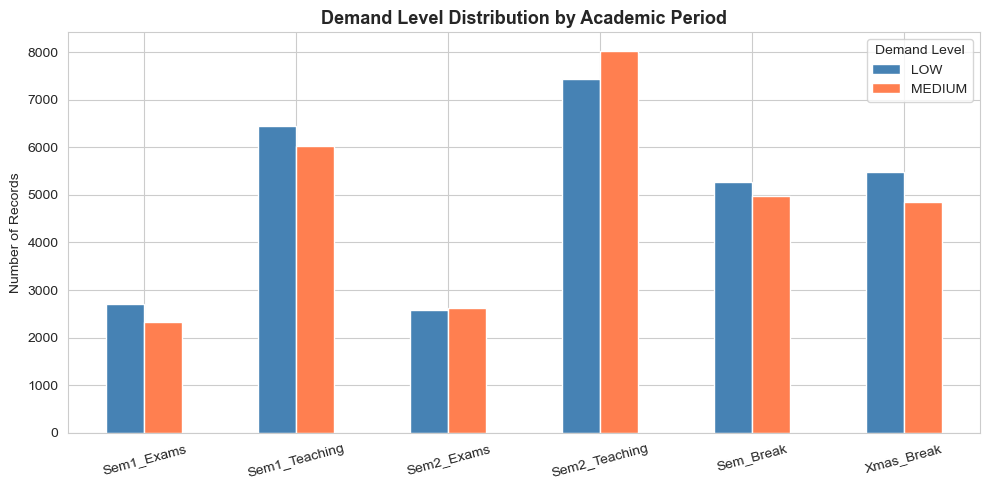

In [42]:
# ── Demand level distribution per academic period ────────────
demand_period = pd.crosstab(df['Academic_Period'], df['Demand_Level'])
demand_period.plot(kind='bar', figsize=(10, 5),
                   color=['steelblue','coral','seagreen'],
                   edgecolor='white', rot=15)
plt.title('Demand Level Distribution by Academic Period',
          fontsize=13, fontweight='bold')
plt.ylabel('Number of Records')
plt.xlabel('')
plt.legend(title='Demand Level')
plt.tight_layout()
plt.show()

---
## 💾 Section 15 — Save Results

Save the lookup table and full results for future use.

In [ ]:
# ── Save portion recommendation lookup table ─────────────────
lookup.to_csv('portion_recommendations.csv', index=False)
print('✅ Saved: portion_recommendations.csv')

# ── Save full results with cluster and anomaly flags ──────────
df[['Date','Cafeteria_ID','Meal','Day_of_Week','Academic_Period',
    'Portions_Sold','Portions_Prepared','Demand_Level',
    'Reconstruction_Error','Anomaly','Label']].to_csv(
    'full_results.csv', index=False
)
print('✅ Saved: full_results.csv')
print()
print('To predict for any day and period, run:')
print('  get_prep_sheet("BBG", "Thursday", "Normal Week")')

---
## ✅ Section 16 — Summary

### What we built
An **unsupervised machine learning system** that tells cafeteria managers 
exactly how many portions of each meal to prepare on any given day.

### How it works
1. The **Autoencoder** learned what a normal cafeteria day looks like by 
   compressing and reconstructing records — no labels required.
2. **K-Means Clustering** grouped similar days into LOW / MEDIUM / HIGH demand patterns 
   by clustering the compressed latent vectors.
3. **Reconstruction error** flagged unusual days the autoencoder struggled to rebuild.
4. The **portion lookup table** maps every (cafeteria × meal × day × period) combination 
   to a concrete preparation quantity with an 8% safety buffer.

### What the manager gains
| Before model | After model |
|---|---|
| Guesses portions daily | Data-driven prep recommendation |
| Same prep every Monday | Different prep for Exam Monday vs Normal Monday |
| Discovers waste after the fact | Waste predicted before cooking |
| No awareness of period patterns | Model auto-adjusts per academic period |

### Key techniques used
- **Autoencoder** — unsupervised neural network for pattern learning
- **K-Means Clustering** — groups latent vectors into demand clusters
- **Silhouette Score** — finds the optimal number of clusters
- **Reconstruction Error** — anomaly detection signal
- **StandardScaler** — normalises features for neural network training
- **EarlyStopping** — prevents overfitting during training